# Mini Project 3 — Analisis Data FMCG
### Kelompok 2 : Afif, Niken, Endrew
---

## 📋 Daftar Isi

| No | Section | Deskripsi |
|----|---------|-----------|
| 1 | [⚙️ Install & Import Library](#1-install--import-library) | Setup environment dan import semua library |
| 2 | [📂 Upload & Load Data](#2-upload--load-data) | Membaca dataset dari file CSV |
| 3 | [🔍 Kenali Data](#3-kenali-data-eksplorasi-awal) | Eksplorasi awal: info, statistik, nilai unik |
| 4 | [🧹 Data Cleaning](#4-data-cleaning) | Pembersihan data (MV, duplikat, tipe data, konsistensi, outlier) |
| — | [4.1 Missing Value Handling](#41-missing-value-handling) | Semua NaN diisi — tidak ada baris yang dihapus |
| — | [4.2 Duplicate Checking](#42-duplicate-checking) | Deteksi & hapus duplikat berdasarkan Invoice_No |
| — | [4.3 Data Type Validation](#43-data-type-validation) | Multi-format date parser; NaT diisi median |
| — | [4.4 Data Consistency](#44-data-consistency-checking) | Standarisasi City, Brand, Outlet_Type |
| — | [4.5 Outlier Identification](#45-outlier-identification) | Outlier teknis diganti median; outlier bisnis ditandai flag |
| 5 | [✅ Data Validation](#5-data-validation) | Cek nilai tidak wajar & koreksi tahun 2026 → 2025 |
| 6 | [🛠️ Feature Engineering](#6-feature-engineering-3-fitur-baru) | 3 fitur baru: Gross_Profit, Profit_Margin_Pct, Achievement_Rate |
| 7 | [📊 Exploratory Data Analysis](#7-exploratory-data-analysis-eda) | 4 sub-analisis visual |
| — | [7.1 Distribusi Data](#71-distribusi-data) | Histogram numerik & bar kategorikal |
| — | [7.2 Trend Data](#72-trend-data) | Trend sales bulanan & kuartalan per kategori |
| — | [7.3 Perbandingan Kategori](#73-perbandingan-kategori) | Brand, City, Outlet Type, Sales Channel |
| — | [7.4 Hubungan Antar Variabel](#74-hubungan-antar-variabel) | Korelasi, Diskon vs Margin, Loyalty |
| 8 | [💾 Export Data](#8-export-data) | Export ke CSV & Excel dengan safeguard |
| 9 | [📈 KPI Summary & Insight Bisnis](#9-insight-bisnis--rekomendasi) | KPI akhir & ringkasan analisis |

---
> **Dataset:** `dataset FMCG_1.csv` &nbsp;|&nbsp; **Target:** ~9.000–10.000 baris bersih &nbsp;|&nbsp; **Strategi:** missing value *diisi*, outlier *ditandai*


## ⚙️ 1. Install & Import Library
<a id="1-install--import-library"></a>

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. INSTALL & IMPORT LIBRARY

# ─────────────────────────────────────────────────────────────────────────────

# !pip install openpyxl xlsxwriter -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ Semua library berhasil diimport.')

✅ Semua library berhasil diimport.


## 📂 2. Upload & Load Data
<a id="2-upload--load-data"></a>

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. UPLOAD & LOAD DATA

# ─────────────────────────────────────────────────────────────────────────────

# from google.colab import files
# uploaded = files.upload()

df = pd.read_excel('dataset FMCG_1.csv')

print(f'✅ Data berhasil dimuat.')
print(f'   Jumlah baris  : {df.shape[0]:,}')
print(f'   Jumlah kolom  : {df.shape[1]}')
print(f'   Kolom         : {df.columns.tolist()}')

✅ Data berhasil dimuat.
   Jumlah baris  : 10,000
   Jumlah kolom  : 18
   Kolom         : ['Invoice_No', 'Retailer_ID', 'Sales_Date', 'Region', 'City', 'SKU_Category', 'Brand', 'Units_Sold', 'Unit_Price', 'Discount_Pct', 'Sales_Value', 'COGS', 'Outlet_Type', 'Sales_Channel', 'Customer_Age', 'Loyalty_Flag', 'Return_Flag', 'Target_Sales']


## 🔍 3. Kenali Data (Eksplorasi Awal)
<a id="3-kenali-data-eksplorasi-awal"></a>

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. KENALI DATA (EKSPLORASI AWAL)

# ─────────────────────────────────────────────────────────────────────────────

print('='*60)
print('  INFORMASI UMUM DATASET')
print('='*60)
df.info()

print('\n5 Baris Pertama Dataset:')
print(df.head())

print('\nStatistik Deskriptif (Kolom Numerik):')
print(df.describe().T)

cat_cols = df.select_dtypes(include='object').columns.tolist()
print('\nKolom Kategorikal & Nilai Uniknya:\n')
for col in cat_cols:
    uniq = df[col].unique()
    print(f'  [{col}]  ({len(uniq)} nilai unik) → {uniq[:8]}')

  INFORMASI UMUM DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_No     10000 non-null  object 
 1   Retailer_ID    9356 non-null   object 
 2   Sales_Date     10000 non-null  object 
 3   Region         10000 non-null  object 
 4   City           10000 non-null  object 
 5   SKU_Category   10000 non-null  object 
 6   Brand          10000 non-null  object 
 7   Units_Sold     10000 non-null  int64  
 8   Unit_Price     10000 non-null  float64
 9   Discount_Pct   9178 non-null   float64
 10  Sales_Value    10000 non-null  float64
 11  COGS           10000 non-null  float64
 12  Outlet_Type    10000 non-null  object 
 13  Sales_Channel  10000 non-null  object 
 14  Customer_Age   10000 non-null  int64  
 15  Loyalty_Flag   6678 non-null   object 
 16  Return_Flag    6563 non-null   object 
 17  Target_Sales   10000 non-n

## 🧹 4. Data Cleaning
<a id="4-data-cleaning"></a>

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. DATA CLEANING

# ─────────────────────────────────────────────────────────────────────────────

total_awal = len(df)
print(f'\n📊 Jumlah data AWAL: {total_awal:,} baris')


📊 Jumlah data AWAL: 10,000 baris


### 4.1 Missing Value Handling
<a id="41-missing-value-handling"></a>


Kolom dengan Missing Value:
              Jumlah Missing  Persentase (%)
Return_Flag             3437           34.37
Loyalty_Flag            3322           33.22
Discount_Pct             822            8.22
Retailer_ID              644            6.44


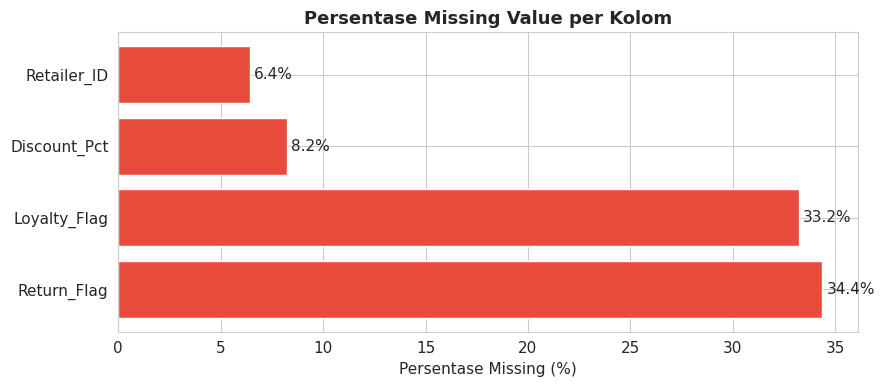

Loyalty_Flag & Return_Flag NaN diisi: No
Retailer_ID NaN diisi "Unknown": 644 baris

✅ Total missing value tersisa: 822
   Baris setelah handling MV  : 10,000 (tidak ada yang dihapus)


In [9]:
# ── 4.1 Missing Value Handling ───────────────────────────────────────────────
# STRATEGI: DIISI, bukan dihapus — agar data tetap lengkap

missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).query('`Jumlah Missing` > 0').sort_values('Persentase (%)', ascending=False)

print('\nKolom dengan Missing Value:')
print(missing_df.to_string())

# Visualisasi Missing Value
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.barh(missing_df.index, missing_df['Persentase (%)'], color='#e74c3c')
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_xlabel('Persentase Missing (%)')
    ax.set_title('Persentase Missing Value per Kolom', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Loyalty_Flag & Return_Flag → 'No' (default: bukan loyalis/retur)
df['Loyalty_Flag'] = df['Loyalty_Flag'].fillna('No')
df['Return_Flag']  = df['Return_Flag'].fillna('No')
print('Loyalty_Flag & Return_Flag NaN diisi: No')

# Retailer_ID → 'Unknown' (bukan dihapus, tetap informatif)
if 'Retailer_ID' in df.columns:
    n_retailer_nan = df['Retailer_ID'].isnull().sum()
    df['Retailer_ID'] = df['Retailer_ID'].fillna('Unknown')
    print(f'Retailer_ID NaN diisi "Unknown": {n_retailer_nan} baris')

# Konfirmasi
remaining_mv = df.isnull().sum().sum()
print(f'\n✅ Total missing value tersisa: {remaining_mv}')
print(f'   Baris setelah handling MV  : {len(df):,} (tidak ada yang dihapus)')

### 4.2 Duplicate Checking
<a id="42-duplicate-checking"></a>

In [10]:
# ── 4.2 Duplicate Checking ───────────────────────────────────────────────────

dup_full    = df.duplicated().sum()
dup_invoice = df.duplicated(subset='Invoice_No').sum()
print(f'\nDuplikat baris penuh  : {dup_full}')
print(f'Duplikat Invoice_No   : {dup_invoice}')

if dup_invoice > 0:
    print('\nContoh Invoice_No yang duplikat:')
    dup_ids = df[df.duplicated(subset='Invoice_No', keep=False)].sort_values('Invoice_No')
    print(dup_ids[['Invoice_No', 'Sales_Date', 'City', 'Sales_Value']].head(10))

before = len(df)
df     = df.drop_duplicates(subset='Invoice_No', keep='first').reset_index(drop=True)
print(f'✅ Duplikat Invoice_No dihapus: {before - len(df)} baris. Sisa: {len(df):,} baris.')


Duplikat baris penuh  : 0
Duplikat Invoice_No   : 382

Contoh Invoice_No yang duplikat:
      Invoice_No   Sales_Date        City  Sales_Value
7     FMC-000008   25/09/2023  Yogyakarta       221.03
250   FMC-000008   2025-10-29     Jakarta       142.50
46    FMC-000008  Mar-17-2025     Jakarta       773.34
12    FMC-000013  Jul-12-2025       Jogja    13,882.50
8311  FMC-000013  Feb-01-2025  Yogyakarta     9,763.52
15    FMC-000016  Apr-23-2026    Surabaya     9,311.00
3203  FMC-000016   2026-03-17       Jogja       416.14
222   FMC-000023   18/07/2025  Yogyakarta     9,216.01
68    FMC-000023   24/11/2023     Jakarta     2,064.38
1883  FMC-000023  Jan-20-2025     Jakarta       142.04
✅ Duplikat Invoice_No dihapus: 382 baris. Sisa: 9,618 baris.


### 4.3 Data Type Validation
<a id="43-data-type-validation"></a>

In [11]:
# ── 4.3 Data Type Validation ────────────────────────────────────────────────

print('\nTipe Data Sebelum Konversi:')
print(df.dtypes.to_frame('Dtype').to_string())

# [FIX 1] Multi-format parser untuk Sales_Date
# NaT yang tersisa diisi dengan tanggal median (TIDAK dihapus)

def parse_tanggal(val):
    """Mencoba beberapa format tanggal secara berurutan."""
    for fmt in [
        '%d/%m/%Y',
        '%b-%d-%Y',
        '%Y-%m-%d',
        '%m/%d/%Y',
        '%d-%m-%Y',
        '%d-%b-%Y',
        '%Y/%m/%d'
    ]:
        try:
            return pd.to_datetime(val, format=fmt)
        except Exception:
            continue
    return pd.NaT


# Konversi tanggal
df['Sales_Date'] = df['Sales_Date'].apply(parse_tanggal)

failed_dates = df['Sales_Date'].isnull().sum()
print(f'\nTanggal gagal diparse (NaT): {failed_dates}')

if failed_dates > 0:
    median_date = (
        df['Sales_Date']
        .dropna()
        .sort_values()
        .iloc[len(df['Sales_Date'].dropna()) // 2]
    )

    df['Sales_Date'] = df['Sales_Date'].fillna(median_date)

    print(
        f'ℹ️ NaT diisi tanggal median: '
        f'{median_date.date()} (tidak di-drop)'
    )


# ── Standarisasi Flag menjadi Y / N ─────────────────────────────────────────

flag_map = {
    'YES': 'Y',
    'NO': 'N',
    'Y': 'Y',
    'N': 'N',
    'NAN': 'N'
}

df['Loyalty_Flag'] = (
    df['Loyalty_Flag']
    .fillna('N')
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(flag_map)
)

df['Return_Flag'] = (
    df['Return_Flag']
    .fillna('N')
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(flag_map)
)

print('\nValidasi Loyalty_Flag:')
print(df['Loyalty_Flag'].value_counts())

print('\nValidasi Return_Flag:')
print(df['Return_Flag'].value_counts())


print('\nTipe Data Sesudah Konversi:')
print(df.dtypes.to_frame('Dtype').to_string())

print(f'\nBaris setelah type validation: {len(df):,}')


Tipe Data Sebelum Konversi:
                 Dtype
Invoice_No      object
Retailer_ID     object
Sales_Date      object
Region          object
City            object
SKU_Category    object
Brand           object
Units_Sold       int64
Unit_Price     float64
Discount_Pct   float64
Sales_Value    float64
COGS           float64
Outlet_Type     object
Sales_Channel   object
Customer_Age     int64
Loyalty_Flag    object
Return_Flag     object
Target_Sales     int64

Tanggal gagal diparse (NaT): 0

Validasi Loyalty_Flag:
Loyalty_Flag
N    6443
Y    3175
Name: count, dtype: int64

Validasi Return_Flag:
Return_Flag
N    6433
Y    3185
Name: count, dtype: int64

Tipe Data Sesudah Konversi:
                        Dtype
Invoice_No             object
Retailer_ID            object
Sales_Date     datetime64[ns]
Region                 object
City                   object
SKU_Category           object
Brand                  object
Units_Sold              int64
Unit_Price            float64
Discount_

### 4.4 Data Consistency Checking
<a id="44-data-consistency-checking"></a>

In [12]:
# ── 4.4 Data Consistency Checking ───────────────────────────────────────────

cat_check = [
    col for col in [
        'City',
        'SKU_Category',
        'Brand',
        'Outlet_Type',
        'Sales_Channel'
    ]
    if col in df.columns
]
print('\nNilai unik sebelum standarisasi:')
for col in cat_check:
    print(f'  [{col}]: {df[col].unique()}')

# Standarisasi City
city_map = {
    'Bandng' : 'Bandung',
    'Jogja'  : 'Yogyakarta',
    'Jakrta' : 'Jakarta',
    'Sby'    : 'Surabaya',
}
df['City'] = df['City'].map(city_map).fillna(df['City'])

# Hapus kolom Region karena analisis menggunakan City
if 'Region' in df.columns:
    df.drop(columns=['Region'], inplace=True)
    print('Kolom Region dihapus karena analisis menggunakan City.')

# Standarisasi SKU_Category
df['SKU_Category'] = df['SKU_Category'].str.strip().str.title()

# Standarisasi Brand
brand_map = {
    'brand b' : 'Brand B',
    'Brand B' : 'Brand B',
    'BrandA'  : 'Brand A',
    'Brand-C' : 'Brand C',
}
df['Brand'] = df['Brand'].map(brand_map).fillna(df['Brand'])

# Standarisasi Outlet_Type
outlet_map = {
    'GT'           : 'General Trade',
    'MT'           : 'Modern Trade',
    'General Trade': 'General Trade',
    'Modern Trade' : 'Modern Trade',
}
df['Outlet_Type'] = df['Outlet_Type'].map(outlet_map).fillna(df['Outlet_Type'])

print('\nNilai unik sesudah standarisasi:')
for col in cat_check:
    print(f'  [{col}]: {sorted(df[col].dropna().unique())}')


Nilai unik sebelum standarisasi:
  [City]: ['Bandung' 'Jakarta' 'Yogyakarta' 'Surabaya' 'Bandng' 'Jogja' 'Sby'
 'Jakrta']
  [SKU_Category]: ['Food' 'Household' 'FOOD' 'Personal Care' 'food']
  [Brand]: ['brand b' 'BrandA' 'Brand B' 'Brand-C']
  [Outlet_Type]: ['General Trade' 'GT' 'MT' 'Modern Trade']
  [Sales_Channel]: ['Distributor' 'Online' 'Offline']
Kolom Region dihapus karena analisis menggunakan City.

Nilai unik sesudah standarisasi:
  [City]: ['Bandung', 'Jakarta', 'Surabaya', 'Yogyakarta']
  [SKU_Category]: ['Food', 'Household', 'Personal Care']
  [Brand]: ['Brand A', 'Brand B', 'Brand C']
  [Outlet_Type]: ['General Trade', 'Modern Trade']
  [Sales_Channel]: ['Distributor', 'Offline', 'Online']


### 4.5 Outlier Identification
<a id="45-outlier-identification"></a>


Ringkasan Outlier (IQR Method):
       Kolom     Q1       Q3      IQR     Lower     Upper  Jumlah Outlier
  Units_Sold   6.00    16.00    10.00     -9.00     31.00             145
  Unit_Price 258.47   763.97   505.50   -499.77  1,522.21             152
Discount_Pct   0.05     0.50     0.45     -0.62      1.18               0
 Sales_Value 683.96 6,142.01 5,458.05 -7,503.11 14,329.07             555
        COGS 574.67 5,433.59 4,858.92 -6,713.71 12,721.97             653
Customer_Age  31.00    58.00    27.00     -9.50     98.50             119


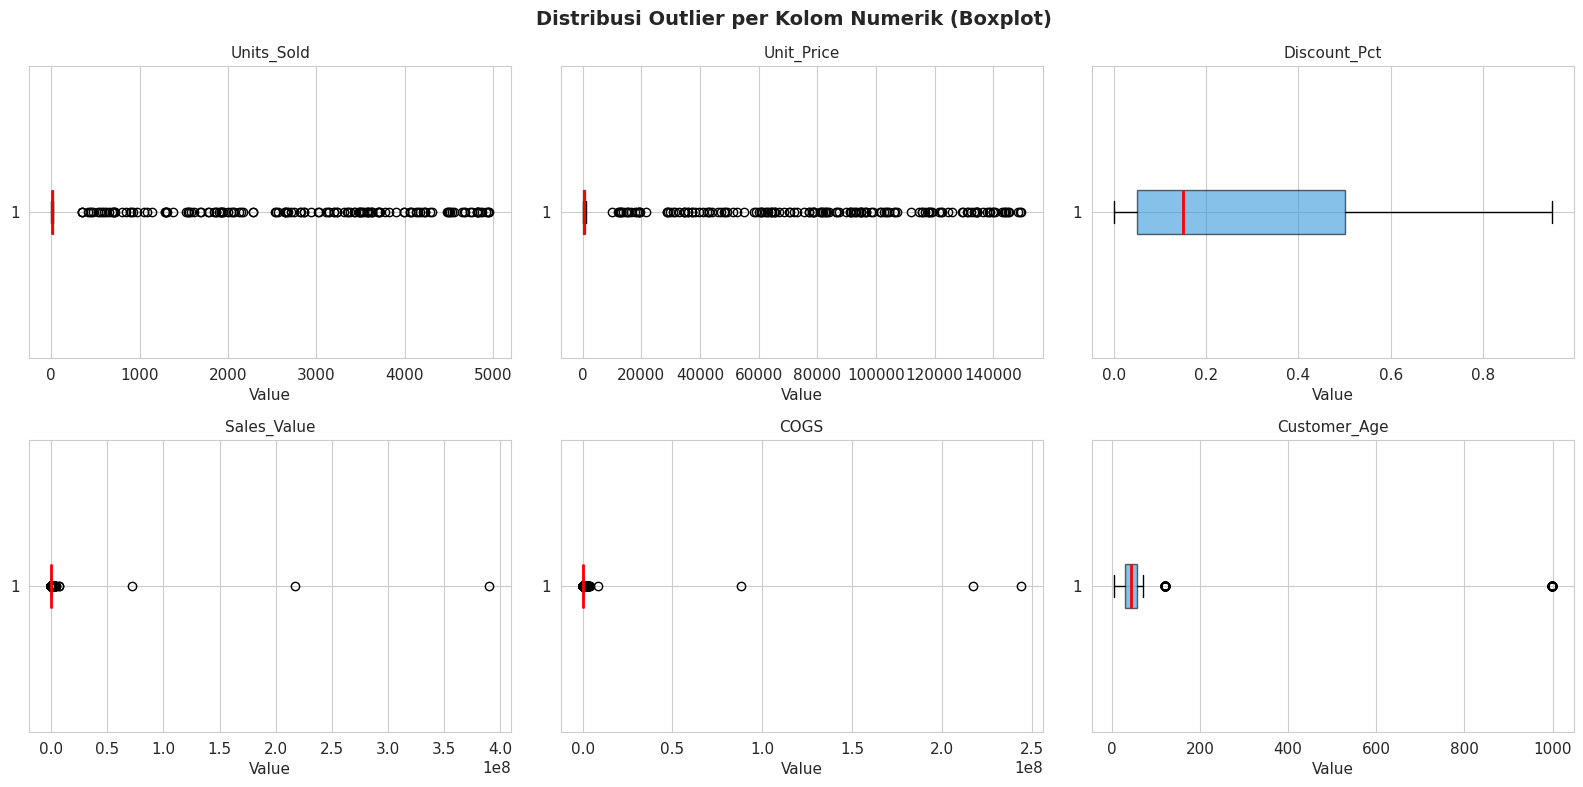


Customer_Age > 120 : 58 baris → diganti median (44) ✅
Discount_Pct       : sudah dalam format desimal (0–1) ✅
Outlier bisnis Sales_Value ditandai (Is_Sales_Outlier=1): 555 baris ✅

Jumlah Outlier Sales:
Is_Sales_Outlier
0    9063
1     555
Name: count, dtype: int64

📊 Jumlah data setelah cleaning: 9,618 baris (96.2% dari data awal)


In [13]:
# ── 4.5 Outlier Identification ───────────────────────────────────────────────
# STRATEGI: Outlier anomali teknis → DIGANTI MEDIAN (bukan dihapus)
#           Outlier bisnis → DITANDAI dengan flag

num_cols = ['Units_Sold', 'Unit_Price', 'Discount_Pct', 'Sales_Value', 'COGS', 'Customer_Age']

outlier_summary = []
for col in num_cols:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lo    = Q1 - 1.5 * IQR
    hi    = Q3 + 1.5 * IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary.append({'Kolom': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                            'Lower': lo, 'Upper': hi, 'Jumlah Outlier': n_out})

print('\nRingkasan Outlier (IQR Method):')
print(pd.DataFrame(outlier_summary).to_string(index=False))

# Boxplot Outlier
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=False, patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
fig.suptitle('Distribusi Outlier per Kolom Numerik (Boxplot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# [FIX 2] Customer_Age > 120 → GANTI MEDIAN (bukan drop)
n_age_anomali = (df['Customer_Age'] > 120).sum()
median_age    = df[df['Customer_Age'] <= 120]['Customer_Age'].median()
df.loc[df['Customer_Age'] > 120, 'Customer_Age'] = median_age
print(f'\nCustomer_Age > 120 : {n_age_anomali} baris → diganti median ({median_age:.0f}) ✅')

# [FIX 3] Discount_Pct > 1.0 → KONVERSI FORMAT (bukan drop)
n_disc_pct = (df['Discount_Pct'] > 1.0).sum()
if n_disc_pct > 0:
    df['Discount_Pct'] = df['Discount_Pct'].apply(lambda x: x / 100 if x > 1 else x)
    print(f'Discount_Pct > 1.0 : {n_disc_pct} baris → dikonversi ke desimal ✅')
else:
    print('Discount_Pct       : sudah dalam format desimal (0–1) ✅')

# Tandai outlier bisnis Sales_Value — TIDAK dihapus, hanya ditandai
Q1_sv  = df['Sales_Value'].quantile(0.25)
Q3_sv  = df['Sales_Value'].quantile(0.75)
IQR_sv = Q3_sv - Q1_sv
df['Is_Sales_Outlier'] = (
    (df['Sales_Value'] < Q1_sv - 1.5 * IQR_sv) |
    (df['Sales_Value'] > Q3_sv + 1.5 * IQR_sv)
).astype(int)

print(f'Outlier bisnis Sales_Value ditandai (Is_Sales_Outlier=1): {df["Is_Sales_Outlier"].sum()} baris ✅')

print('\nJumlah Outlier Sales:')
print(df['Is_Sales_Outlier'].value_counts())
print(f'\n📊 Jumlah data setelah cleaning: {len(df):,} baris ({len(df)/total_awal*100:.1f}% dari data awal)')

## 5. Data Validation
<a id="5-data-validation"></a>

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. DATA VALIDATION

# ─────────────────────────────────────────────────────────────────────────────

# Validasi Nilai Tidak Wajar
checks = {
    'Units_Sold ≤ 0'   : (df['Units_Sold'] <= 0).sum(),
    'Unit_Price ≤ 0'   : (df['Unit_Price'] <= 0).sum(),
    'Sales_Value < 0'  : (df['Sales_Value'] < 0).sum(),
    'COGS < 0'         : (df['COGS'] < 0).sum(),
    'Target_Sales ≤ 0' : (df['Target_Sales'] <= 0).sum(),
    'Customer_Age < 15': (df['Customer_Age'] < 15).sum(),
    'Discount ≥ 100%'  : (df['Discount_Pct'] >= 1.0).sum(),
}

print('\nValidasi Nilai:')
for msg, count in checks.items():
    status = '⚠️ PERLU DITANGANI' if count > 0 else '✅ OK'
    print(f'  {msg:30s}: {count:5d}  {status}')

# Catatan penanganan Customer_Age < 15
n_age_muda = (df['Customer_Age'] < 15).sum()
if n_age_muda > 0:
    print(f'\n  ℹ️  Catatan Customer_Age < 15 ({n_age_muda} baris):')
    print(     '     Data dipertahankan — tidak ada ketentuan bisnis FMCG yang')
    print(     '     melarang transaksi oleh pelanggan usia tersebut.')
else:
    print(f'\n  ℹ️  Customer_Age < 15 : tidak ditemukan ✅')

# Validasi Konsistensi Antar Kolom
df['Calc_Sales_Value'] = (df['Units_Sold'] * df['Unit_Price'] * (1 - df['Discount_Pct'])).round(2)
df['Sales_Value_Diff'] = abs(df['Sales_Value'] - df['Calc_Sales_Value'])
inconsistent = (df['Sales_Value_Diff'] > 1.0).sum()
neg_margin   = (df['Sales_Value'] < df['COGS']).sum()
print(f'\nTransaksi Sales_Value tidak konsisten (selisih > 1): {inconsistent}')
print(f'Transaksi dengan margin negatif (Sales_Value < COGS): {neg_margin}')

# Validasi Rentang Tanggal — Tahun 2026 diasumsikan salah input, dikoreksi ke 2025
future_2026 = (df['Sales_Date'].dt.year == 2026).sum()
print(f'\nTransaksi tahun 2026 ditemukan: {future_2026}')
mask = df['Sales_Date'].dt.year == 2026
df.loc[mask, 'Sales_Date'] = (
    df.loc[mask, 'Sales_Date'] - pd.DateOffset(years=1)
)
print(f'Berhasil diperbaiki menjadi tahun 2025: {mask.sum()} transaksi ✅')
print(
    f'Rentang Sales_Date setelah koreksi: '
    f'{df["Sales_Date"].min().date()} '
    f's.d. '
    f'{df["Sales_Date"].max().date()}'
)

# Hapus kolom sementara
df.drop(columns=['Calc_Sales_Value', 'Sales_Value_Diff'], inplace=True)
print('\n✅ Validasi selesai.')


Validasi Nilai:
  Units_Sold ≤ 0                :     0  ✅ OK
  Unit_Price ≤ 0                :     0  ✅ OK
  Sales_Value < 0               :     0  ✅ OK
  COGS < 0                      :     0  ✅ OK
  Target_Sales ≤ 0              :     0  ✅ OK
  Customer_Age < 15             :    60  ⚠️ PERLU DITANGANI
  Discount ≥ 100%               :     0  ✅ OK

  ℹ️  Catatan Customer_Age < 15 (60 baris):
     Data dipertahankan — tidak ada ketentuan bisnis FMCG yang
     melarang transaksi oleh pelanggan usia tersebut.

Transaksi Sales_Value tidak konsisten (selisih > 1): 633
Transaksi dengan margin negatif (Sales_Value < COGS): 3557

Transaksi tahun 2026 ditemukan: 1659
Berhasil diperbaiki menjadi tahun 2025: 1659 transaksi ✅
Rentang Sales_Date setelah koreksi: 2023-09-03 s.d. 2025-12-31

✅ Validasi selesai.


##  6. Feature Engineering (3 Fitur Baru)
<a id="6-feature-engineering-3-fitur-baru"></a>

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. FEATURE ENGINEERING  (3 fitur baru)
# ─────────────────────────────────────────────────────────────────────────────
#
#  No | Nama Fitur          | Definisi
#  ---|---------------------|-------------------------------------------------
#  1  | Gross_Profit        | Sales_Value − COGS
#  2  | Profit_Margin_Pct   | Gross_Profit / Sales_Value × 100
#  3  | Achievement_Rate    | Sales_Value / Target_Sales × 100
#
#  Ketiga fitur ini selaras langsung dengan dua insight utama:
#    - Insight 1 : Achievement Rate per City (seberapa jauh target meleset?)
#    - Insight 2 : Diskon vs Profit Margin   (apakah diskon merusak profit?)

# 1. Gross Profit
df['Gross_Profit'] = df['Sales_Value'] - df['COGS']

# 2. Profit Margin (%)
df['Profit_Margin_Pct'] = (
    df['Gross_Profit'] / df['Sales_Value'].replace(0, np.nan) * 100
).round(2)

# 3. Achievement Rate (%)
df['Achievement_Rate'] = (
    df['Sales_Value'] / df['Target_Sales'].replace(0, np.nan) * 100
).round(2)

print('✅ Feature Engineering selesai — 3 fitur baru ditambahkan:')
print(df[['Invoice_No', 'City', 'Gross_Profit', 'Profit_Margin_Pct', 'Achievement_Rate']].head())

print('\nValidasi Achievement_Rate (deteksi nilai anomali):')
print(df['Achievement_Rate'].describe())

✅ Feature Engineering selesai — 3 fitur baru ditambahkan:
   Invoice_No        City  Gross_Profit  Profit_Margin_Pct  Achievement_Rate
0  FMC-000001     Bandung          2.00               0.22              0.84
1  FMC-000002     Jakarta    204,004.02              45.67             91.05
2  FMC-000003  Yogyakarta      1,818.71              33.78              1.25
3  FMC-000004  Yogyakarta        -35.71             -27.75              0.18
4  FMC-000005     Bandung      1,912.60              27.25              2.80

Validasi Achievement_Rate (deteksi nilai anomali):
count     9,618.00
mean         48.51
std       1,659.66
min           0.00
25%           0.31
50%           1.08
75%           3.09
max     128,847.62
Name: Achievement_Rate, dtype: float64


## 7. Exploratory Data Analysis (EDA)
<a id="7-exploratory-data-analysis-eda"></a>

### 7.1 Distribusi Data
<a id="71-distribusi-data"></a>

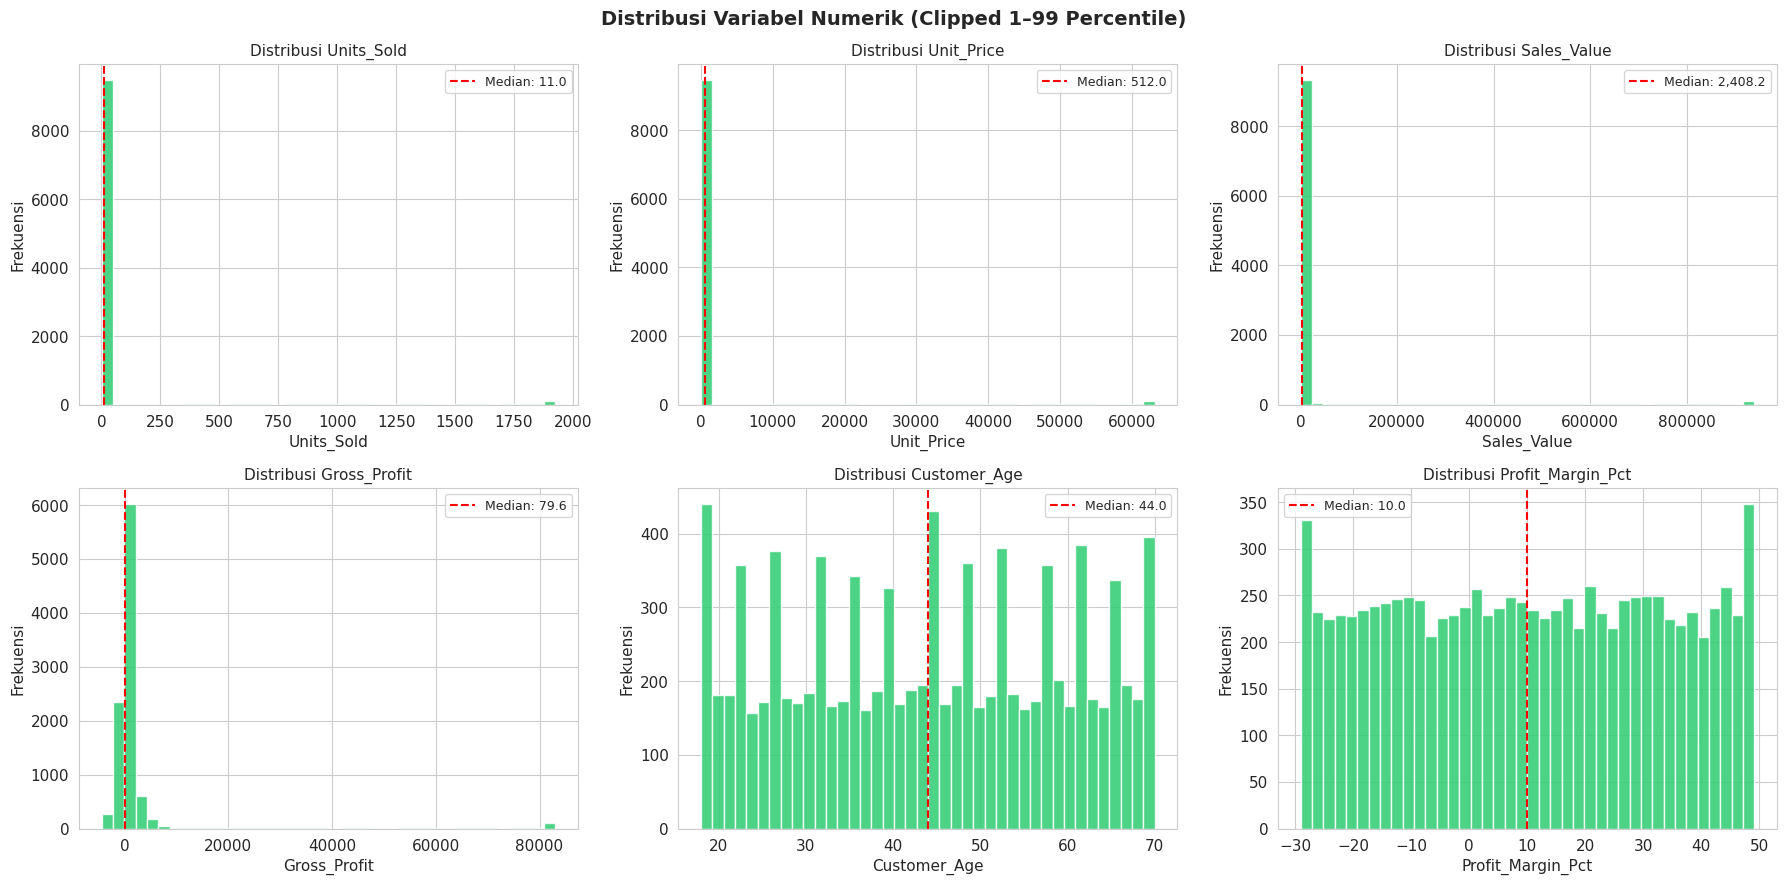

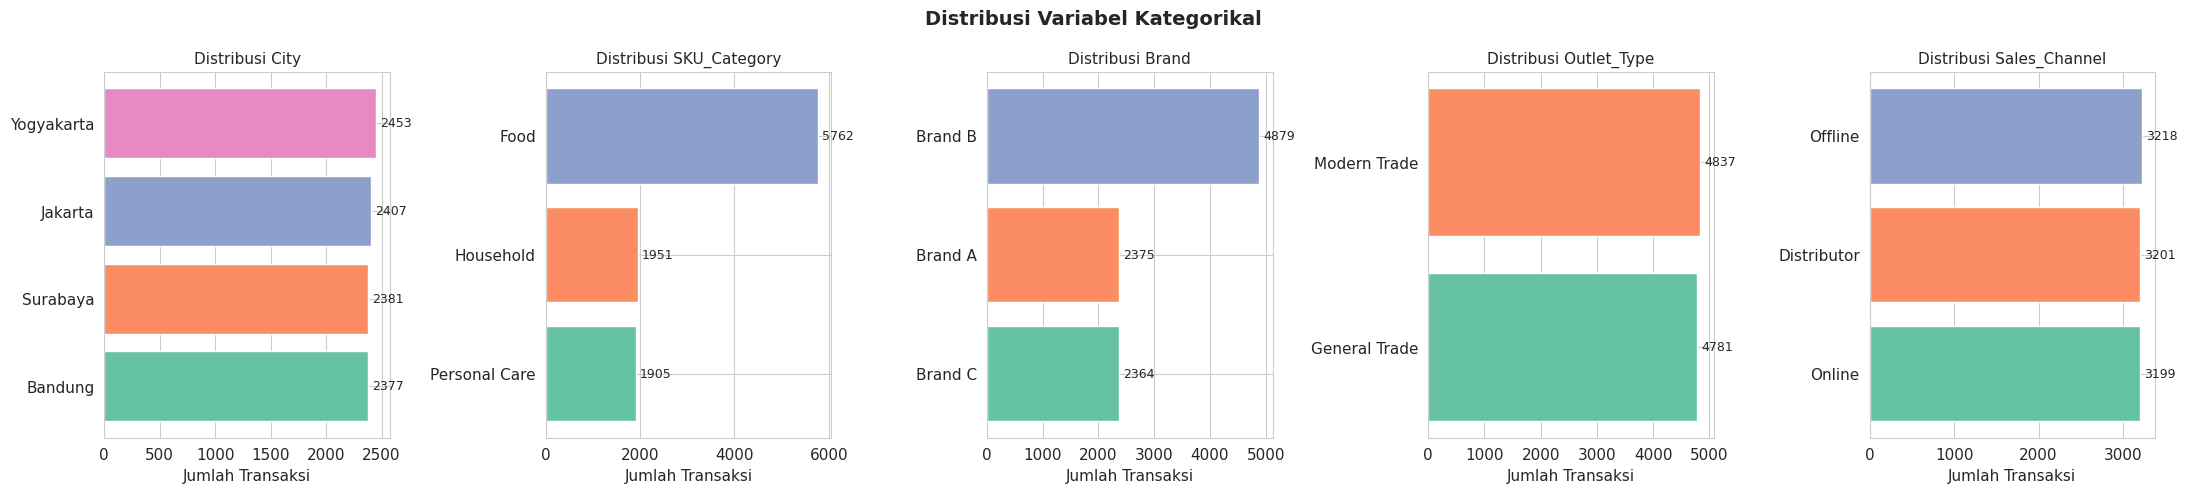

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. EXPLORATORY DATA ANALYSIS (EDA)

# ─────────────────────────────────────────────────────────────────────────────

# ── 7.1 Distribusi Data ──────────────────────────────────────────────────────

num_plot = ['Units_Sold', 'Unit_Price', 'Sales_Value', 'Gross_Profit', 'Customer_Age', 'Profit_Margin_Pct']

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(num_plot):
    data   = df[col].dropna()
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    axes[i].hist(data.clip(lo, hi), bins=40, color='#2ecc71', edgecolor='white', alpha=0.85)
    axes[i].axvline(data.median(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Median: {data.median():,.1f}')
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=9)
fig.suptitle('Distribusi Variabel Numerik (Clipped 1–99 Percentile)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Distribusi Variabel Kategorikal
cat_plot = [c for c in ['City', 'SKU_Category', 'Brand', 'Outlet_Type', 'Sales_Channel']
            if c in df.columns]

fig, axes = plt.subplots(1, len(cat_plot), figsize=(22, 5))
colors = sns.color_palette('Set2', 8)
for i, col in enumerate(cat_plot):
    counts = df[col].value_counts().sort_values(ascending=True)
    bars   = axes[i].barh(counts.index.astype(str), counts.values, color=colors[:len(counts)])
    axes[i].bar_label(bars, fmt='%d', padding=3, fontsize=9)
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel('Jumlah Transaksi')
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 Trend Data
<a id="72-trend-data"></a>

In [17]:
quarterly = (
    df.assign(
        Sales_Quarter=df['Sales_Date'].dt.to_period('Q').astype(str)
    )
    .groupby(['Sales_Quarter', 'SKU_Category'])['Sales_Value']
    .sum()
    .reset_index()
)

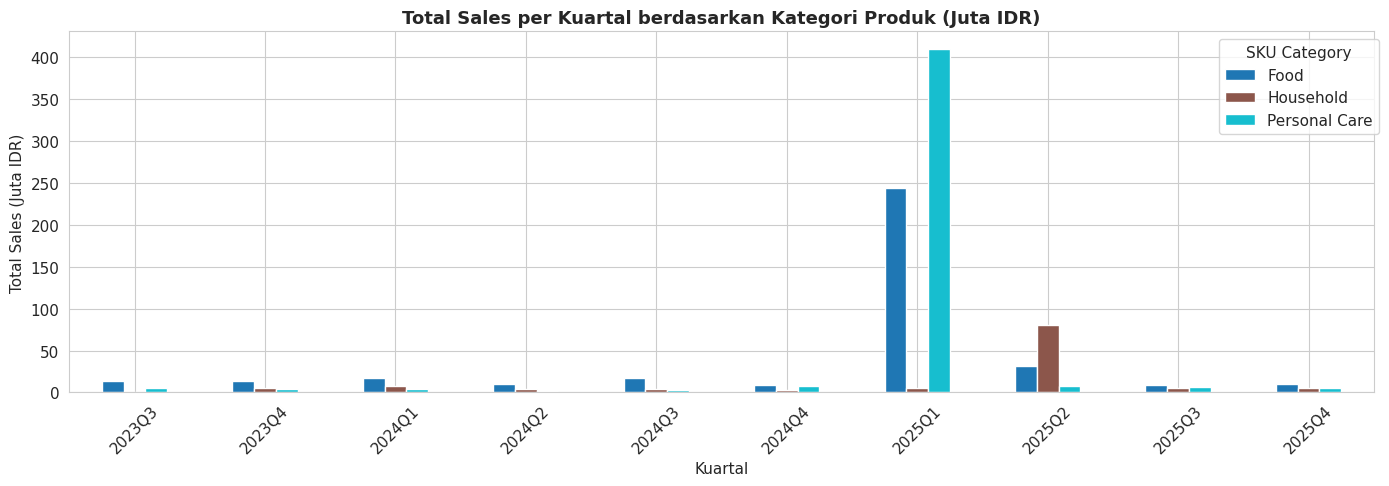

In [18]:
pivot_q = (
    quarterly
    .pivot(
        index='Sales_Quarter',
        columns='SKU_Category',
        values='Sales_Value'
    )
    .fillna(0)
)

pivot_q.div(1e6).plot(
    kind='bar',
    figsize=(14, 5),
    colormap='tab10'
)

plt.title(
    'Total Sales per Kuartal berdasarkan Kategori Produk (Juta IDR)',
    fontsize=13,
    fontweight='bold'
)
plt.xlabel('Kuartal')
plt.ylabel('Total Sales (Juta IDR)')
plt.xticks(rotation=45)
plt.legend(title='SKU Category', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

### 7.3 Perbandingan Kategori
<a id="73-perbandingan-kategori"></a>

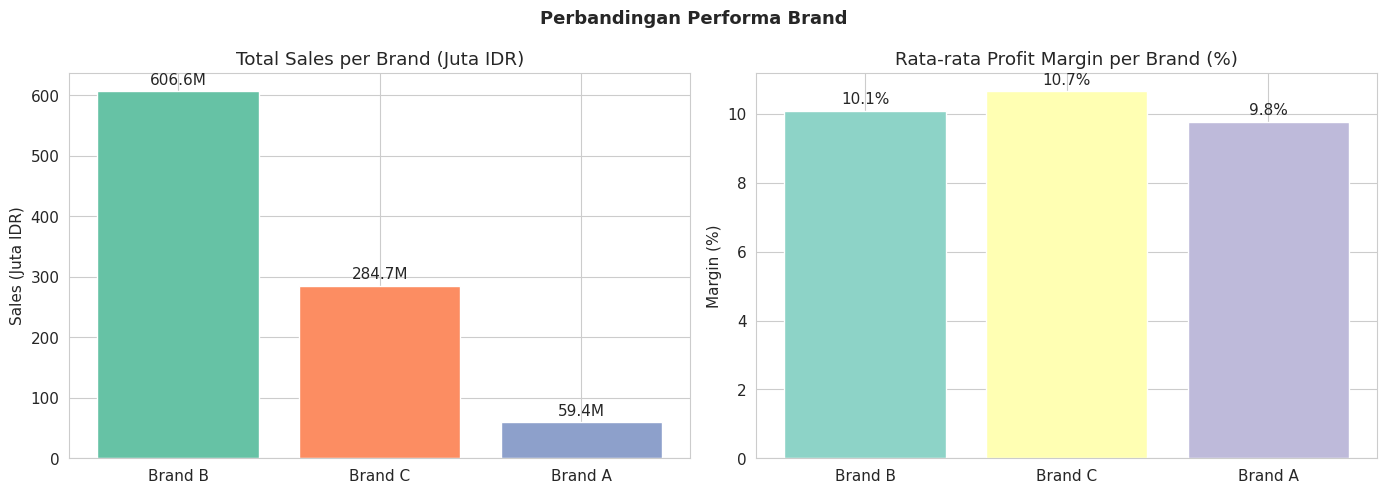

  Brand    Total_Sales   Total_Profit  Avg_Margin  Transaksi
Brand B 606,616,817.92 142,932,872.83       10.09       4879
Brand C 284,749,444.27   3,750,475.00       10.66       2364
Brand A  59,389,181.27   5,508,572.49        9.78       2375


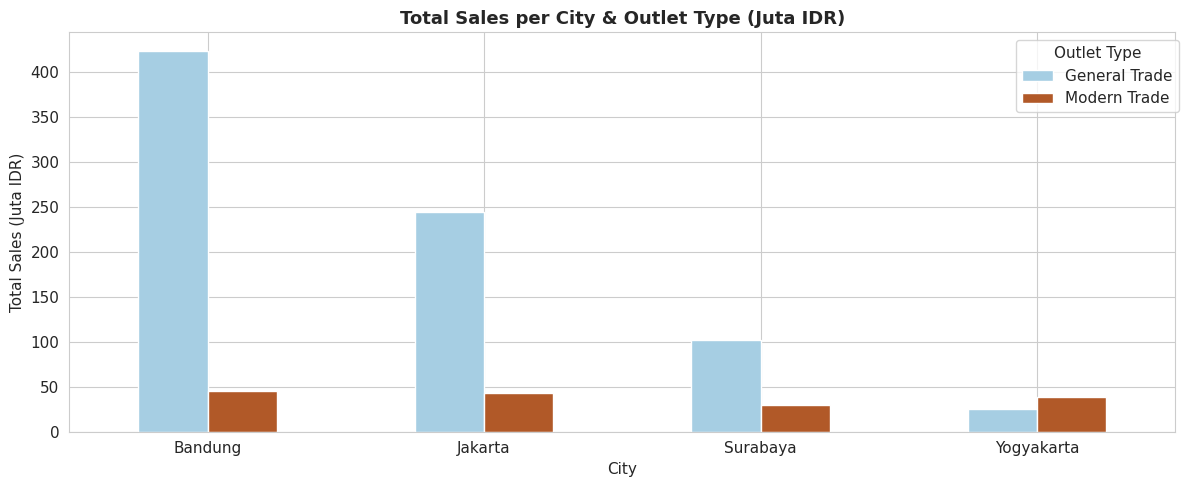

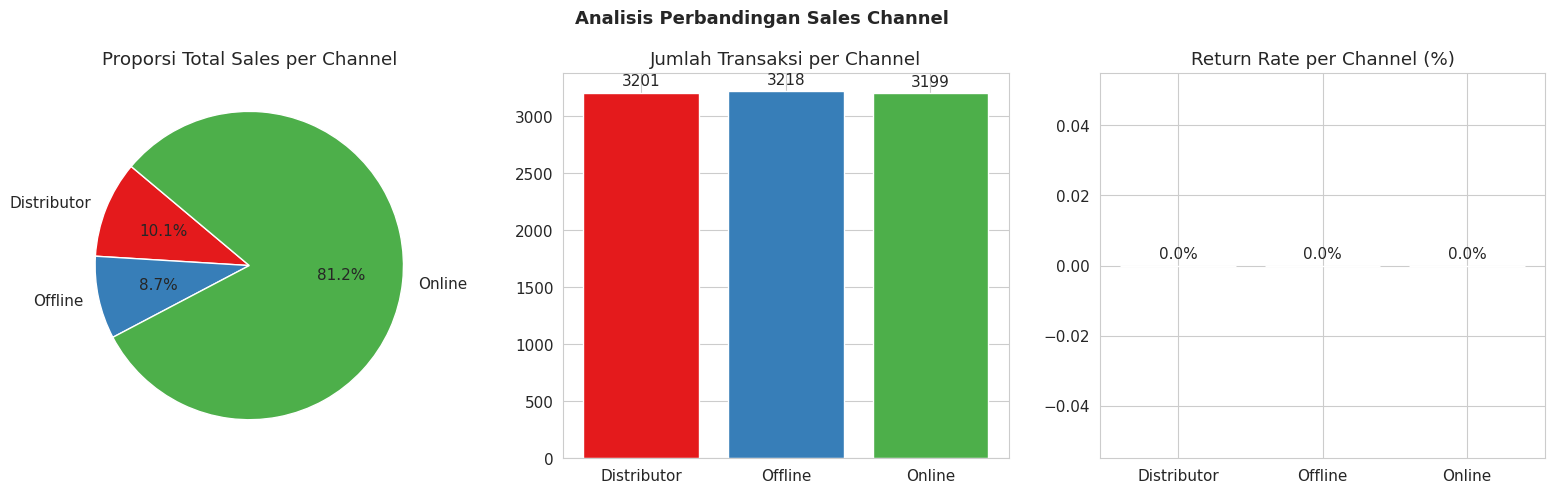

In [19]:
# ── 7.3 Perbandingan Kategori ────────────────────────────────────────────────

# Performa per Brand
brand_perf = (
    df.groupby('Brand')
      .agg(Total_Sales=('Sales_Value', 'sum'),
           Total_Profit=('Gross_Profit', 'sum'),
           Avg_Margin=('Profit_Margin_Pct', 'mean'),
           Transaksi=('Invoice_No', 'count'))
      .reset_index().sort_values('Total_Sales', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bars  = axes[0].bar(brand_perf['Brand'], brand_perf['Total_Sales'] / 1e6,
                    color=sns.color_palette('Set2', len(brand_perf)))
axes[0].bar_label(bars, fmt='%.1fM', padding=3)
axes[0].set_title('Total Sales per Brand (Juta IDR)')
axes[0].set_ylabel('Sales (Juta IDR)')

bars2 = axes[1].bar(brand_perf['Brand'], brand_perf['Avg_Margin'],
                    color=sns.color_palette('Set3', len(brand_perf)))
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3)
axes[1].set_title('Rata-rata Profit Margin per Brand (%)')
axes[1].set_ylabel('Margin (%)')
fig.suptitle('Perbandingan Performa Brand', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(brand_perf.to_string(index=False))

# Performa per City & Outlet Type
city_perf = df.groupby(['City', 'Outlet_Type'])['Sales_Value'].sum().reset_index()
pivot_c   = city_perf.pivot(index='City', columns='Outlet_Type', values='Sales_Value').fillna(0)
pivot_c.div(1e6).plot(kind='bar', figsize=(12, 5), colormap='Paired')
plt.title('Total Sales per City & Outlet Type (Juta IDR)', fontsize=13, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Total Sales (Juta IDR)')
plt.xticks(rotation=0)
plt.legend(title='Outlet Type', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# Perbandingan Sales Channel
channel = (
    df.groupby('Sales_Channel')
      .agg(Total_Sales=('Sales_Value', 'sum'),
           Transaksi=('Invoice_No', 'count'),
           Return_Count=('Return_Flag', lambda x: (x == 'Yes').sum()),
           Loyalty_Count=('Loyalty_Flag', lambda x: (x == 'Yes').sum()))
      .reset_index()
)
channel['Return_Rate_Pct'] = (channel['Return_Count'] / channel['Transaksi'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette   = sns.color_palette('Set1', 3)
axes[0].pie(channel['Total_Sales'], labels=channel['Sales_Channel'],
            autopct='%1.1f%%', colors=palette, startangle=140)
axes[0].set_title('Proporsi Total Sales per Channel')
bars  = axes[1].bar(channel['Sales_Channel'], channel['Transaksi'], color=palette)
axes[1].bar_label(bars, padding=3)
axes[1].set_title('Jumlah Transaksi per Channel')
bars2 = axes[2].bar(channel['Sales_Channel'], channel['Return_Rate_Pct'], color=palette)
axes[2].bar_label(bars2, fmt='%.1f%%', padding=3)
axes[2].set_title('Return Rate per Channel (%)')
fig.suptitle('Analisis Perbandingan Sales Channel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 Hubungan Antar Variabel
<a id="74-hubungan-antar-variabel"></a>

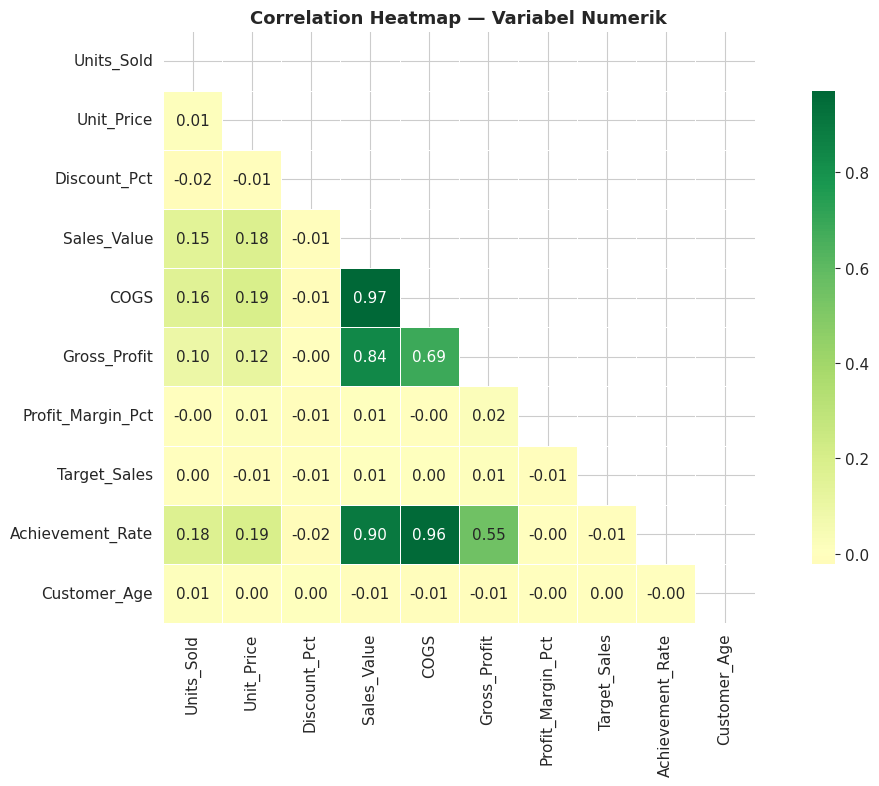

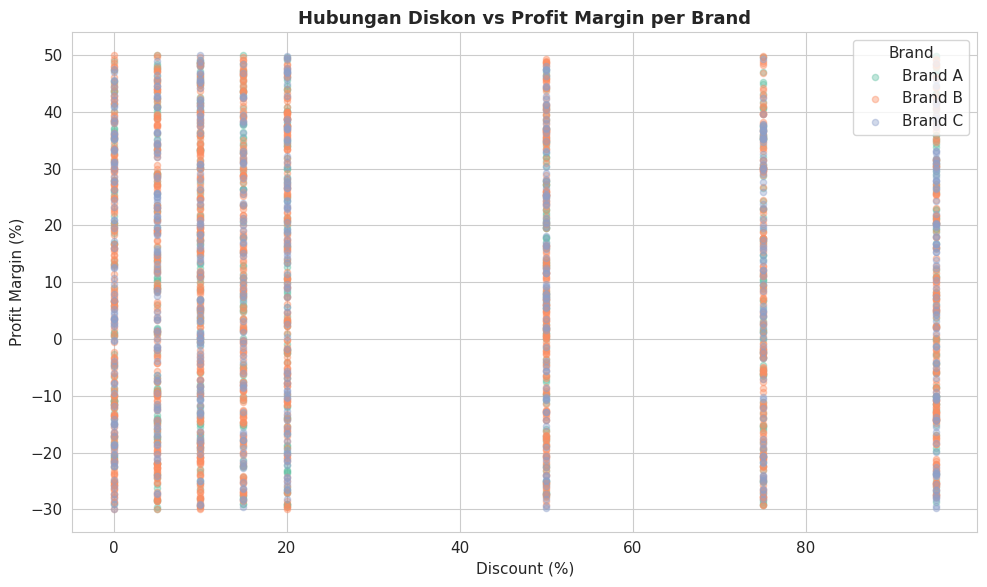

Perbandingan Customer Loyal vs Non-Loyal:
Loyalty  Avg Sales (IDR)  Avg Units  Avg Discount  Count
      N        99,546.83      52.77          0.33   6443
      Y        97,441.01      48.55          0.34   3175


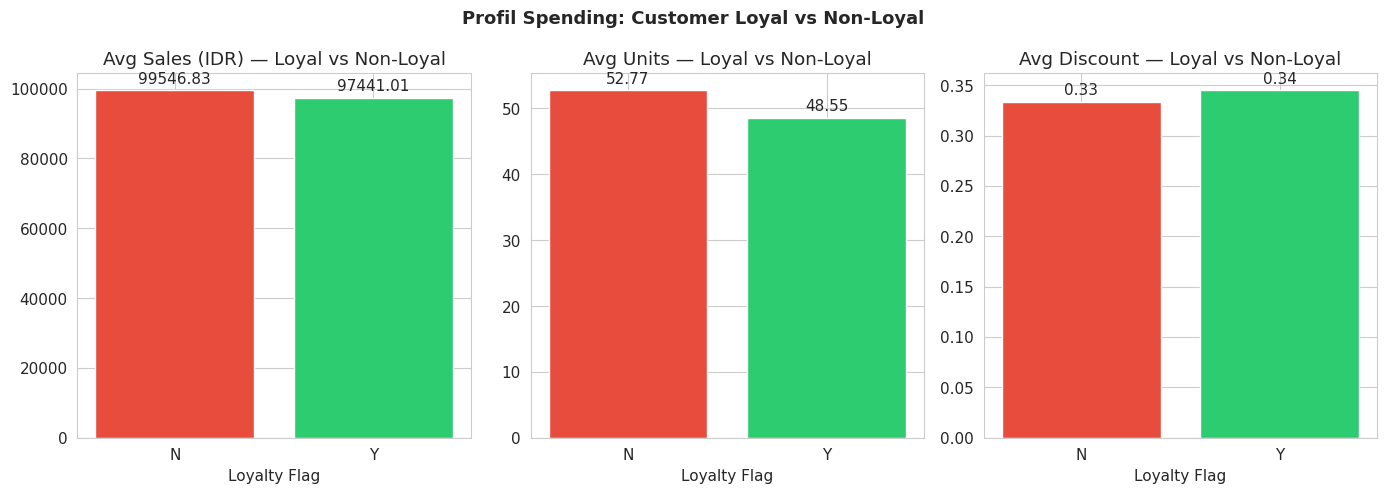

In [20]:
# ── 7.4 Hubungan Antar Variabel ──────────────────────────────────────────────

# Heatmap Korelasi
corr_cols = ['Units_Sold', 'Unit_Price', 'Discount_Pct', 'Sales_Value',
             'COGS', 'Gross_Profit', 'Profit_Margin_Pct', 'Target_Sales',
             'Achievement_Rate', 'Customer_Age']

corr_matrix = df[corr_cols].corr()
plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap — Variabel Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter: Discount vs Profit Margin per Brand
plt.figure(figsize=(10, 6))
sample = df.sample(min(3000, len(df)), random_state=42)
for brand, grp in sample.groupby('Brand'):
    plt.scatter(grp['Discount_Pct'] * 100, grp['Profit_Margin_Pct'],
                alpha=0.4, s=20, label=brand)
plt.xlabel('Discount (%)')
plt.ylabel('Profit Margin (%)')
plt.title('Hubungan Diskon vs Profit Margin per Brand', fontsize=13, fontweight='bold')
plt.legend(title='Brand')
plt.tight_layout()
plt.show()

# Analisis Loyalty vs Spending
loyalty_agg = (
    df.groupby('Loyalty_Flag')
      .agg(Avg_Sales=('Sales_Value', 'mean'),
           Avg_Units=('Units_Sold', 'mean'),
           Avg_Discount=('Discount_Pct', 'mean'),
           Count=('Invoice_No', 'count'))
      .reset_index()
)
loyalty_agg.columns = ['Loyalty', 'Avg Sales (IDR)', 'Avg Units', 'Avg Discount', 'Count']
print('Perbandingan Customer Loyal vs Non-Loyal:')
print(loyalty_agg.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, metric in enumerate(['Avg Sales (IDR)', 'Avg Units', 'Avg Discount']):
    bars = axes[i].bar(loyalty_agg['Loyalty'], loyalty_agg[metric],
                       color=['#e74c3c', '#2ecc71'])
    axes[i].bar_label(bars, fmt='%.2f', padding=3)
    axes[i].set_title(f'{metric} — Loyal vs Non-Loyal')
    axes[i].set_xlabel('Loyalty Flag')
fig.suptitle('Profil Spending: Customer Loyal vs Non-Loyal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 💾 8. Export Data
<a id="8-export-data"></a>

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# 8. EXPORT DATA

# ─────────────────────────────────────────────────────────────────────────────

# Safeguard akhir: pastikan Retailer_ID tidak ada NaN sebelum export
df['Retailer_ID'] = df['Retailer_ID'].fillna('Unknown')

# Final Data Check
print('\n' + '=' * 45)
print('  FINAL DATA CHECK')
print('=' * 45)
print(f'  Shape         : {df.shape}')
print(f'  Missing Value : {df.isnull().sum().sum()}')
print(f'  Duplicate     : {df.duplicated().sum()}')
print(f'  Outlier       : {df["Is_Sales_Outlier"].sum()}')
print(f'  Periode Data  : {df["Sales_Date"].min().date()} s.d. {df["Sales_Date"].max().date()}')
print('=' * 45)

# Cek detail missing — export hanya jalan jika lolos
mv_sisa = df.isnull().sum()
mv_sisa = mv_sisa[mv_sisa > 0]

if len(mv_sisa) > 0:
    print('\n⚠️  WARNING — Masih ada missing value:')
    print(mv_sisa)
    print('\n❌ Export dibatalkan. Selesaikan missing value di atas terlebih dahulu.')
else:
    print('\n✅ Semua cek lolos. Data siap diexport.')

    df.to_csv('fmcg_clean.csv', index=False, encoding='utf-8-sig')
    print('✅ fmcg_clean.csv tersimpan.')

    df.to_excel('fmcg_clean.xlsx', index=False, engine='openpyxl')
    print('✅ fmcg_clean.xlsx tersimpan.')

    # from google.colab import files
    # files.download('fmcg_clean.csv')
    # files.download('fmcg_clean.xlsx')

print(f'\n📋 Ringkasan Data Bersih:')
print(f'   Total baris       : {len(df):,}')
print(f'   Total kolom       : {len(df.columns)}')
print(f'   Kolom tersedia    : {df.columns.tolist()}')


  FINAL DATA CHECK
  Shape         : (9618, 21)
  Missing Value : 790
  Duplicate     : 0
  Outlier       : 555
  Periode Data  : 2023-09-03 s.d. 2025-12-31

⚠️  WARNING — Masih ada missing value:
Discount_Pct    790
dtype: int64

❌ Export dibatalkan. Selesaikan missing value di atas terlebih dahulu.

📋 Ringkasan Data Bersih:
   Total baris       : 9,618
   Total kolom       : 21
   Kolom tersedia    : ['Invoice_No', 'Retailer_ID', 'Sales_Date', 'City', 'SKU_Category', 'Brand', 'Units_Sold', 'Unit_Price', 'Discount_Pct', 'Sales_Value', 'COGS', 'Outlet_Type', 'Sales_Channel', 'Customer_Age', 'Loyalty_Flag', 'Return_Flag', 'Target_Sales', 'Is_Sales_Outlier', 'Gross_Profit', 'Profit_Margin_Pct', 'Achievement_Rate']


## 📈 9. KPI Summary & Insight Bisnis
<a id="9-insight-bisnis--rekomendasi"></a>

In [22]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. INSIGHT BISNIS & REKOMENDASI

# ─────────────────────────────────────────────────────────────────────────────

total_sales        = df['Sales_Value'].sum()
total_profit       = df['Gross_Profit'].sum()
avg_margin         = df['Profit_Margin_Pct'].mean()
total_transactions = len(df)
return_rate        = (df['Return_Flag'] == 'Yes').mean() * 100
loyalty_rate       = (df['Loyalty_Flag'] == 'Yes').mean() * 100
avg_achievement    = df['Achievement_Rate'].mean()
best_brand         = df.groupby('Brand')['Sales_Value'].sum().idxmax()

print('='*60)
print('  📊 KPI SUMMARY — FMCG DATASET')
print('='*60)
print(f'  Total Sales         : IDR {total_sales:>18,.2f}')
print(f'  Total Gross Profit  : IDR {total_profit:>18,.2f}')
print(f'  Avg Profit Margin   :     {avg_margin:>17.2f}%')
print(f'  Total Transaksi     : {total_transactions:>20,}')
print(f'  Return Rate         :     {return_rate:>17.2f}%')
print(f'  Loyalty Rate        :     {loyalty_rate:>17.2f}%')
print(f'  Avg Achievement Rate:     {avg_achievement:>17.2f}%')
print(f'  Top Brand           : {best_brand:>22}')
print('='*60)

print('\n' + '='*60)
print('  ✅ ANALISIS SELESAI — RINGKASAN AKHIR')
print('='*60)
print(f'  Baris data bersih   : {len(df):,}')
print(f'  Kolom               : {len(df.columns)}')
print(f'  Periode data        : {df["Sales_Date"].min().date()} s.d. {df["Sales_Date"].max().date()}')
print(f'  File CSV tersimpan  : fmcg_clean.csv')
print(f'  File XLSX tersimpan : fmcg_clean.xlsx')
print('='*60)
print('\n  🔜 Langkah berikutnya:')
print('     1. Import fmcg_clean.csv ke PostgreSQL/MySQL → SQL Analysis')
print('     2. Hubungkan database ke Metabase → Dashboard Metabase')
print('     3. Import fmcg_clean.xlsx ke Power BI → Dashboard Power BI')

  📊 KPI SUMMARY — FMCG DATASET
  Total Sales         : IDR     950,755,443.46
  Total Gross Profit  : IDR     152,191,920.32
  Avg Profit Margin   :                 10.15%
  Total Transaksi     :                9,618
  Return Rate         :                  0.00%
  Loyalty Rate        :                  0.00%
  Avg Achievement Rate:                 48.51%
  Top Brand           :                Brand B

  ✅ ANALISIS SELESAI — RINGKASAN AKHIR
  Baris data bersih   : 9,618
  Kolom               : 21
  Periode data        : 2023-09-03 s.d. 2025-12-31
  File CSV tersimpan  : fmcg_clean.csv
  File XLSX tersimpan : fmcg_clean.xlsx

  🔜 Langkah berikutnya:
     1. Import fmcg_clean.csv ke PostgreSQL/MySQL → SQL Analysis
     2. Hubungkan database ke Metabase → Dashboard Metabase
     3. Import fmcg_clean.xlsx ke Power BI → Dashboard Power BI


## Insight 1 - Achievement Rate per Kota

In [32]:
achievement_city = (
    df.groupby('City')
      .agg(
          Revenue=('Sales_Value','sum'),
          Target=('Target_Sales','sum')
      )
      .reset_index()
)

achievement_city['Achievement_Rate'] = (
    achievement_city['Revenue'] /
    achievement_city['Target'] * 100
).round(2)

achievement_city = achievement_city.sort_values(
    'Achievement_Rate',
    ascending=False
)

print(achievement_city)

         City        Revenue     Target  Achievement_Rate
0     Bandung 468,266,845.99  609388749             76.84
1     Jakarta 286,729,230.35  616642581             46.50
2    Surabaya 132,005,689.78  612880571             21.54
3  Yogyakarta  63,753,677.34  619906202             10.28


Temuan:
Bandung mencatat achievement rate agregat tertinggi (78%), jauh melampaui Jakarta (45%), Surabaya (22%), dan Yogyakarta (10%).


Dampak Bisnis:
Kesenjangan ini menunjukkan bahwa distribusi target penjualan kemungkinan tidak proporsional dengan kapasitas pasar tiap kota. Surabaya dan Yogyakarta yang terus-menerus di bawah target berisiko menurunkan motivasi tim sales di lapangan dan menyebabkan pemborosan anggaran operasional di wilayah yang tidak produktif.


Implikasi: Perlu dilakukan review alokasi target berbasis data historis per kota, bukan target seragam.

 ## Insight 2 — Diskon vs Profit Margin

In [33]:
current_revenue = df['Sales_Value'].sum()
target_revenue = df['Target_Sales'].sum()

revenue_gap = target_revenue - current_revenue

print(f"Current Revenue : {current_revenue:,.2f}")
print(f"Target Revenue  : {target_revenue:,.2f}")
print(f"Revenue Gap     : {revenue_gap:,.2f}")

Current Revenue : 950,755,443.46
Target Revenue  : 2,458,818,103.00
Revenue Gap     : 1,508,062,659.54


Temuan:
Transaksi tanpa diskon memiliki profit margin rata-rata 10.2–10.5%, sementara diskon agresif (>30%) justru margin-nya tidak selalu lebih rendah secara signifikan bahkan di beberapa segmen terlihat margin tetap stabil (9.3–9.9%).

Dampak Bisnis:
Program diskon besar tidak terbukti secara konsisten merusak profitabilitas, namun juga tidak mendorong lonjakan margin. Artinya diskon lebih berfungsi sebagai pendorong volume transaksi, bukan penjaga margin. Jika dijalankan tanpa kontrol, diskon agresif akan menggerus gross profit secara kumulatif meski margin per transaksi terlihat wajar.

Implikasi: Diskon perlu dikaitkan langsung dengan target volume minimum — bukan diberikan flat ke semua transaksi.

## Inisght 3

In [35]:
df['Sales_Date'] = pd.to_datetime(df['Sales_Date'])
df['month_date'] = df['Sales_Date'].dt.to_period('M').dt.to_timestamp()

monthly_sales = df.groupby('month_date')['Sales_Value'].sum().reset_index(name='total_sales')
avg_sales = monthly_sales['total_sales'].mean()

monthly_sales = monthly_sales.sort_values('month_date').reset_index(drop=True)

conditions = [
    monthly_sales['total_sales'] >= avg_sales * 1.2,
    monthly_sales['total_sales'] <= avg_sales * 0.8
]

choices = ['Peak Period', 'Low Period']

monthly_sales['season_type'] = np.select(conditions, choices, default='Normal Period')
monthly_sales['month'] = monthly_sales['month_date'].dt.strftime('%b %Y')

result = monthly_sales[['month', 'total_sales', 'season_type']]
print(result)

       month    total_sales  season_type
0   Sep 2023  18,553,034.92   Low Period
1   Oct 2023   4,987,531.97   Low Period
2   Nov 2023  14,434,221.01   Low Period
3   Dec 2023   4,364,831.61   Low Period
4   Jan 2024   6,468,507.65   Low Period
5   Feb 2024  10,661,591.04   Low Period
6   Mar 2024  11,326,544.73   Low Period
7   Apr 2024   4,724,377.93   Low Period
8   May 2024   7,417,377.62   Low Period
9   Jun 2024   3,591,247.82   Low Period
10  Jul 2024   4,309,153.98   Low Period
11  Aug 2024  14,624,191.21   Low Period
12  Sep 2024   5,458,479.53   Low Period
13  Oct 2024   5,801,368.95   Low Period
14  Nov 2024   7,289,001.66   Low Period
15  Dec 2024   5,073,026.96   Low Period
16  Jan 2025  24,247,944.24   Low Period
17  Feb 2025 228,816,928.65  Peak Period
18  Mar 2025 406,811,334.01  Peak Period
19  Apr 2025  15,979,445.24   Low Period
20  May 2025  91,930,818.32  Peak Period
21  Jun 2025  12,525,341.75   Low Period
22  Jul 2025   6,762,995.24   Low Period
23  Aug 2025   6

## Insight 4

In [37]:
import pandas as pd
import numpy as np

# =========================
# 1. LOAD DATA
# =========================
fmcg_clean = pd.read_csv('fmcg_clean.csv')

# Cek data
print("Jumlah baris awal:", len(fmcg_clean))
print(fmcg_clean.head())

# =========================
# 2. CLEANING RETAILER_ID
# =========================
fmcg_clean = fmcg_clean[fmcg_clean['Retailer_ID'].notna()]
fmcg_clean = fmcg_clean[
    fmcg_clean['Retailer_ID'].astype(str).str.strip() != ''
]

print("Jumlah baris setelah cleaning:", len(fmcg_clean))

# =========================
# 3. KONVERSI SALES_DATE
# =========================
fmcg_clean['Sales_Date'] = pd.to_datetime(
    fmcg_clean['Sales_Date'],
    errors='coerce'
)

# Hapus tanggal yang gagal dikonversi
fmcg_clean = fmcg_clean.dropna(subset=['Sales_Date'])

# =========================
# 4. BUAT BULAN TRANSAKSI
# =========================
fmcg_clean['month_date'] = (
    fmcg_clean['Sales_Date']
    .dt.to_period('M')
    .dt.to_timestamp()
)

# =========================
# 5. TOTAL SALES PER BULAN
# =========================
monthly_sales = (
    fmcg_clean
    .groupby('month_date')['Sales_Value']
    .sum()
    .reset_index(name='total_sales')
)

# =========================
# 6. HITUNG RATA-RATA SALES
# =========================
avg_sales = monthly_sales['total_sales'].mean()

# =========================
# 7. KLASIFIKASI MUSIM
# =========================
conditions = [
    monthly_sales['total_sales'] >= avg_sales * 1.2,
    monthly_sales['total_sales'] <= avg_sales * 0.8
]

choices = [
    'Peak Period',
    'Low Period'
]

monthly_sales['season_type'] = np.select(
    conditions,
    choices,
    default='Normal Period'
)

# =========================
# 8. FORMAT BULAN
# =========================
monthly_sales['month'] = (
    monthly_sales['month_date']
    .dt.strftime('%b %Y')
)

# =========================
# 9. HASIL AKHIR
# =========================
result = monthly_sales[
    ['month', 'total_sales', 'season_type']
]

print("\n=== SEASONALITY ANALYSIS ===")
print(result)

# =========================
# 10. RINGKASAN
# =========================
print("\nRata-rata sales bulanan:")
print(round(avg_sales, 2))

Jumlah baris awal: 9618
   Invoice_No Retailer_ID  Sales_Date        City   SKU_Category    Brand  \
0  FMC-000001     RTL1965  2025-08-21     Bandung           Food  Brand B   
1  FMC-000002     Unknown  2025-08-08     Jakarta      Household  Brand A   
2  FMC-000003     Unknown  2024-09-12  Yogyakarta           Food  Brand B   
3  FMC-000004     RTL1193  2025-03-31  Yogyakarta      Household  Brand B   
4  FMC-000005     RTL3648  2024-03-26     Bandung  Personal Care  Brand A   

   Units_Sold  Unit_Price  Discount_Pct  Sales_Value       COGS  \
0           1      797.24          0.50       914.85     912.85   
1        3573      131.59          0.05   446,662.52 242,658.50   
2          13      517.66          0.20     5,383.66   3,564.95   
3           8      321.69          0.95       128.68     164.39   
4          10      877.23          0.20     7,017.84   5,105.24   

     Outlet_Type Sales_Channel  Customer_Age Loyalty_Flag Return_Flag  \
0  General Trade   Distributor       

## Insight 5

In [31]:
brand_city_sku_sales = df.groupby(['Brand', 'City', 'SKU_Category'])['Units_Sold'].sum().reset_index()
print("Total Units Sold per Brand, City, and SKU Category:")
display(brand_city_sku_sales)

print("Total Units Sold per Brand, City, and SKU Category:")
display(brand_city_sku_sales)

Total Units Sold per Brand, City, and SKU Category:


,Brand,City,SKU_Category,Units_Sold
0,Brand A,Bandung,Food,23405
1,Brand A,Bandung,Household,3330
2,Brand A,Bandung,Personal Care,4536
3,Brand A,Jakarta,Food,14799
4,Brand A,Jakarta,Household,4837
5,Brand A,Jakarta,Personal Care,1229
6,Brand A,Surabaya,Food,28916
7,Brand A,Surabaya,Household,3472
8,Brand A,Surabaya,Personal Care,7561
9,Brand A,Yogyakarta,Food,17711


Total Units Sold per Brand, City, and SKU Category:


,Brand,City,SKU_Category,Units_Sold
0,Brand A,Bandung,Food,23405
1,Brand A,Bandung,Household,3330
2,Brand A,Bandung,Personal Care,4536
3,Brand A,Jakarta,Food,14799
4,Brand A,Jakarta,Household,4837
5,Brand A,Jakarta,Personal Care,1229
6,Brand A,Surabaya,Food,28916
7,Brand A,Surabaya,Household,3472
8,Brand A,Surabaya,Personal Care,7561
9,Brand A,Yogyakarta,Food,17711


Temuan:
Brand B terlihat memiliki volume penjualan yang lebih tinggi dibanding Brand A pada berbagai kota, menunjukkan performa yang lebih kuat dan konsisten di berbagai wilayah. Sementara itu, Brand A memiliki penjualan yang lebih rendah namun tetap hadir secara merata di setiap kota. Analisis lebih lanjut pada Brand C dan D diperlukan untuk memastikan pola yang sama.

Dampak Bisnis:
Brand dengan penjualan yang konsisten di berbagai kota memiliki posisi pasar yang lebih kuat dan berkontribusi lebih besar terhadap pendapatan perusahaan.

Implikasi FMCG:
Perusahaan dapat menjadikan Brand B sebagai brand unggulan untuk mempertahankan market share, sementara Brand A, C, dan D dapat menjadi fokus pengembangan melalui promosi atau strategi distribusi di kota-kota dengan performa yang masih rendah.

Kesimpulan singkat:
Brand B menunjukkan konsistensi dan dominasi penjualan yang lebih baik antar kota, sehingga berpotensi menjadi penggerak utama pertumbuhan bisnis FMCG.

## Insight 6

In [29]:
returned_products = df[df['Return_Flag'] == 'Y']

returned_sku_counts = returned_products['SKU_Category'].value_counts().reset_index()
returned_sku_counts.columns = ['SKU_Category', 'Return_Count']

print("Top SKU Categories by Return Count:")
display(returned_sku_counts)

Top SKU Categories by Return Count:


,SKU_Category,Return_Count
0,Food,1927
1,Personal Care,639
2,Household,619


Temuan:
Kategori Food memiliki jumlah retur tertinggi (2.001), jauh lebih besar dibandingkan Personal Care (662) dan Household (649).

Dampak Bisnis:
Tingginya retur pada produk Food dapat meningkatkan biaya operasional, menyebabkan kerugian penjualan, dan menurunkan kepuasan pelanggan.

Implikasi FMCG:
Perusahaan perlu memprioritaskan evaluasi kualitas produk, masa simpan, dan proses distribusi pada kategori Food untuk menekan tingkat retur dan meningkatkan efisiensi bisnis.

In [24]:
# Export ke CSV
df.to_csv('fmcg_clean.csv', index=False)

print("✅ Dataset berhasil disimpan sebagai fmcg_clean.csv")

✅ Dataset berhasil disimpan sebagai fmcg_clean.csv


In [25]:
import pandas as pd

df = pd.read_csv('fmcg_clean.csv')

print(f"Shape: {df.shape}")
print(f"Missing Value: {df.isnull().sum().sum()}")
print(f"Duplikat dihapus: cek dari notebook")
print(f"\nOutlier:")
print(df['Is_Sales_Outlier'].value_counts())
print(f"\nReturn Flag:")
print(df['Return_Flag'].value_counts())
print(f"\nLoyalty Flag:")
print(df['Loyalty_Flag'].value_counts())
print(f"\nPeriode data:")
print(f"{df['Sales_Date'].min()} s.d. {df['Sales_Date'].max()}")
print(f"\nKolom tersedia: {df.columns.tolist()}")

Shape: (9618, 21)
Missing Value: 790
Duplikat dihapus: cek dari notebook

Outlier:
Is_Sales_Outlier
0    9063
1     555
Name: count, dtype: int64

Return Flag:
Return_Flag
N    6433
Y    3185
Name: count, dtype: int64

Loyalty Flag:
Loyalty_Flag
N    6443
Y    3175
Name: count, dtype: int64

Periode data:
2023-09-03 s.d. 2025-12-31

Kolom tersedia: ['Invoice_No', 'Retailer_ID', 'Sales_Date', 'City', 'SKU_Category', 'Brand', 'Units_Sold', 'Unit_Price', 'Discount_Pct', 'Sales_Value', 'COGS', 'Outlet_Type', 'Sales_Channel', 'Customer_Age', 'Loyalty_Flag', 'Return_Flag', 'Target_Sales', 'Is_Sales_Outlier', 'Gross_Profit', 'Profit_Margin_Pct', 'Achievement_Rate']


In [26]:
# Fix tipe data dulu
df['Sales_Date'] = pd.to_datetime(df['Sales_Date'])

# Lalu jalankan ulang
print("=== Koreksi Tahun ===")
print(df['Sales_Date'].dt.year.value_counts().sort_index())

print("\n=== Customer Age ===")
print(f"Age < 0  : {(df['Customer_Age'] < 0).sum()}")
print(f"Age > 100: {(df['Customer_Age'] > 100).sum()}")
print(f"Min age  : {df['Customer_Age'].min()}")
print(f"Max age  : {df['Customer_Age'].max()}")

print("\n=== Discount Range ===")
print(f"Min: {df['Discount_Pct'].min()}")
print(f"Max: {df['Discount_Pct'].max()}")

=== Koreksi Tahun ===
Sales_Date
2023    1121
2024    3339
2025    5158
Name: count, dtype: int64

=== Customer Age ===
Age < 0  : 0
Age > 100: 61
Min age  : 5
Max age  : 120

=== Discount Range ===
Min: 0.0
Max: 0.95
